In [1]:
import sqlite3

In [2]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()


In [3]:
cursor.execute("DROP TABLE IF EXISTS sales")

In [4]:
cursor.execute('''
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT,
        quantity INTEGER,
        price REAL,
        category TEXT,
        date TEXT,
        region TEXT
    )
''')


In [5]:
sales_data = [
    ("Apples", 10, 1.5, "Fruit", "2025-04-01", "North"),
    ("Bananas", 20, 0.8, "Fruit", "2025-04-01", "South"),
    ("Cherries", 15, 2.0, "Fruit", "2025-04-02", "East"),
    ("Chips", 30, 1.0, "Snack", "2025-04-03", "West"),
    ("Soda", 25, 1.2, "Drink", "2025-04-03", "North"),
    ("Bananas", 10, 0.8, "Fruit", "2025-04-04", "South"),
    ("Apples", 5, 1.5, "Fruit", "2025-04-05", "East")
]

In [6]:
cursor.executemany('''
    INSERT INTO sales (product, quantity, price, category, date, region)
    VALUES (?, ?, ?, ?, ?, ?)
''', sales_data)

In [18]:
conn.commit()
conn.close()

ProgrammingError: Cannot operate on a closed database.

In [8]:
import sqlite3
import pandas as pd

In [9]:
conn = sqlite3.connect("sales_data.db")

In [19]:
query_all = "SELECT * FROM sales"

In [11]:
df_all = pd.read_sql_query(query_all, conn)
print("Full Sales Table:")
print(df_all)

Full Sales Table:
   id   product  quantity  price category        date region
0   1    Apples        10    1.5    Fruit  2025-04-01  North
1   2   Bananas        20    0.8    Fruit  2025-04-01  South
2   3  Cherries        15    2.0    Fruit  2025-04-02   East
3   4     Chips        30    1.0    Snack  2025-04-03   West
4   5      Soda        25    1.2    Drink  2025-04-03  North
5   6   Bananas        10    0.8    Fruit  2025-04-04  South
6   7    Apples         5    1.5    Fruit  2025-04-05   East


In [12]:
query_summary = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

In [13]:
df_summary = pd.read_sql_query(query_summary, conn)
print("\nSales Summary:")
print(df_summary)


Sales Summary:
    product  total_qty  revenue
0    Apples         15     22.5
1   Bananas         30     24.0
2  Cherries         15     30.0
3     Chips         30     30.0
4      Soda         25     30.0


In [14]:
conn.close()

In [15]:
import matplotlib.pyplot as plt

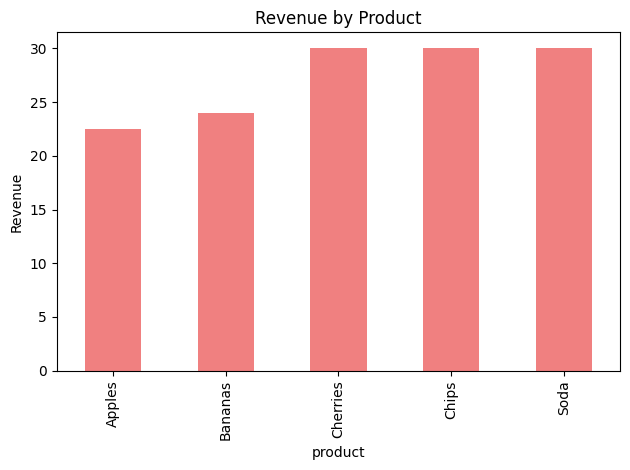

In [16]:
df_summary.plot(kind='bar', x='product', y='revenue', legend=False, color='lightcoral')
plt.ylabel("Revenue")
plt.title("Revenue by Product")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Saves the chart image
plt.show()